# Лабораторная работа E4 — Оценка уровня мышечной активности

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e4.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e4.html)**.

**Что разбираем.** Сырой ЭМГ выглядит как шум: он одинаково часто уходит вверх
и вниз, поэтому его среднее близко к нулю независимо от силы сокращения.
Информация о силе лежит не в знаке, а в **размахе**.

Чтобы её достать, сигнал режут на короткие **окна** и в каждом считают
среднеквадратичное значение:

$$\mathrm{RMS} = \sqrt{\frac{1}{W}\sum_{i=1}^{W} x_i^2}$$

Получается **огибающая** — гладкая кривая, повторяющая форму сокращения.
Именно она потом превращается в команду «сжать клешню на столько-то процентов».

Главный компромисс лабы: **длина окна**. Короткое окно быстро реагирует, но
дрожит; длинное даёт гладкую кривую, но запаздывает.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


## Ячейка 2 · Вспомогательные функции

Генератор правдоподобного ЭМГ с известной огибающей, скользящий RMS и
рисование. Запусти один раз и дальше просто вызывай.

In [2]:
def bump(t, center, width, amp):
    """Плавный «холм» — одно сокращение мышцы."""
    d = (t - center) / width
    return np.where(np.abs(d) < 1, amp * 0.5 * (1 + np.cos(np.pi * d)), 0.0)


def make_emg(fs, dur, contractions=((0.8, 0.45, 1.0), (2.05, 0.5, 0.6)),
             rest=0.07, seed=0):
    """Синтетический ЭМГ: шумовая несущая, промодулированная огибающей.

    contractions: список (центр, полуширина, амплитуда) в секундах.
    Возвращает (t, raw, envelope, carrier) — истинная огибающая известна,
    поэтому оценку можно с ней честно сравнить.
    """
    n = int(dur * fs)
    t = np.arange(n) / fs
    envelope = rest + sum(bump(t, c, w, a) for c, w, a in contractions)
    rng = np.random.default_rng(seed)
    carrier = rng.uniform(-1, 1, n)
    return t, envelope * carrier, envelope, carrier


def moving_rms(x, width, causal=True):
    """Скользящий RMS через накопленную сумму квадратов — быстро и без циклов.

    causal=True  — окно смотрит только назад (так работает реальное время);
    causal=False — окно центрировано (только офлайн, зато без сдвига).
    """
    n = len(x)
    cumulative = np.concatenate(([0.0], np.cumsum(x ** 2)))
    out = np.empty(n)
    for i in range(n):
        if causal:
            lo, hi = max(0, i - width + 1), i + 1
        else:
            half = width // 2
            lo, hi = max(0, i - half), min(n, i + half + 1)
        out[i] = np.sqrt((cumulative[hi] - cumulative[lo]) / (hi - lo))
    return out


def estimate_envelope(raw, carrier, fs, win_ms, causal=True):
    """RMS-огибающая, отмасштабированная так, чтобы её можно было сравнить
    с истинной огибающей (сырой RMS занижен на RMS несущей)."""
    width = max(1, int(win_ms / 1000 * fs))
    scale = np.sqrt(np.mean(carrier ** 2))
    return moving_rms(raw, width, causal) / scale, width


def plot_envelope(t, raw, true_env, estimates, title=""):
    """Сырой сигнал, истинная огибающая и одна или несколько оценок."""
    fig, ax = plt.subplots(figsize=(11, 4.6))
    ax.plot(t, raw, color="0.78", lw=0.6, label="сырой ЭМГ")
    ax.plot(t, true_env, "--", color="green", lw=1.8, label="истинная огибающая")
    for label, values in estimates:
        ax.plot(t, values, lw=1.9, label=label)
    ax.set(xlabel="$t$, с", ylabel="амплитуда",
           title=title or "Скользящий RMS как огибающая сокращения")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

## Ячейка 3 · Сырой сигнал и его огибающая

Сначала посмотрим, почему среднее не годится, а RMS годится.

Среднее сырого сигнала : +0.0064  ← около нуля, силу не показывает
RMS сырого сигнала     : 0.2500  ← растёт вместе с сокращением


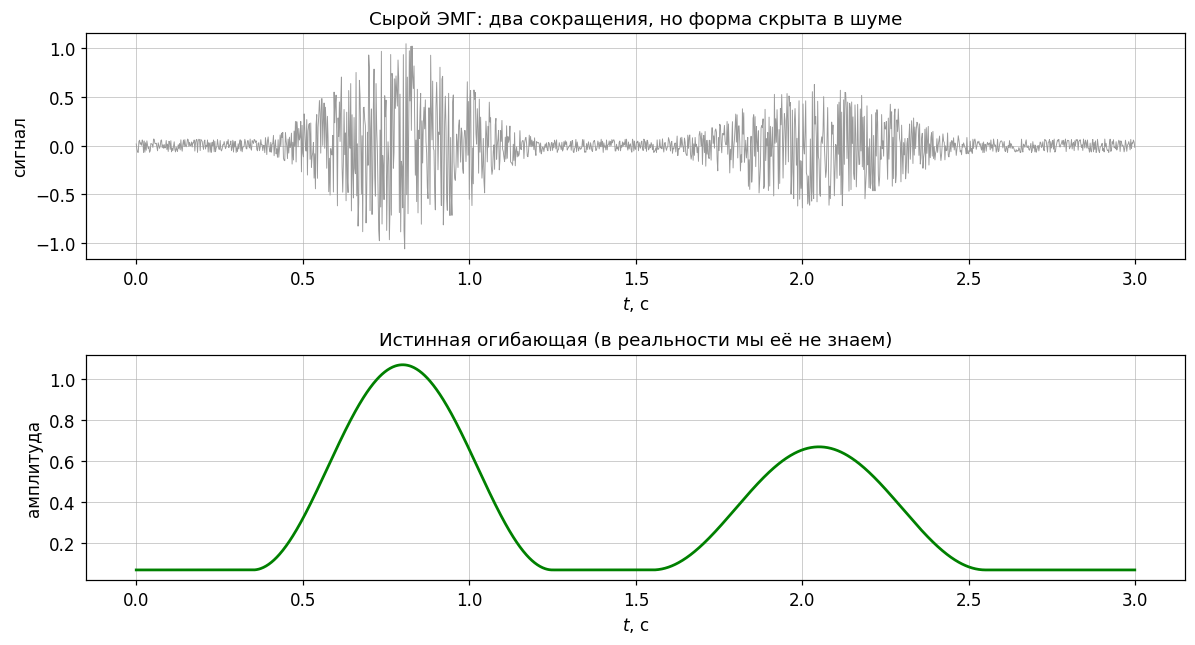

In [3]:
FS = 500.0    # частота дискретизации, Гц
DUR = 3.0     # длительность записи, с

t, raw, true_env, carrier = make_emg(FS, DUR)

print("Среднее сырого сигнала : %+.4f  ← около нуля, силу не показывает" % raw.mean())
print("RMS сырого сигнала     : %.4f  ← растёт вместе с сокращением" % np.sqrt(np.mean(raw ** 2)))

fig, ax = plt.subplots(2, 1, figsize=(11, 6))
ax[0].plot(t, raw, color="0.6", lw=0.6)
ax[0].set(xlabel="$t$, с", ylabel="сигнал", title="Сырой ЭМГ: два сокращения, но форма скрыта в шуме")
ax[1].plot(t, true_env, color="green", lw=1.8)
ax[1].set(xlabel="$t$, с", ylabel="амплитуда", title="Истинная огибающая (в реальности мы её не знаем)")
fig.tight_layout()
plt.show()

## Ячейка 4 · Оценка огибающей скользящим RMS

Меняй `WIN_MS` и `CAUSAL` — это те же ползунок и переключатель, что в
браузерной версии.

Окно 60 мс = 30 отсчётов
Режим: каузальный (реальное время)
Ожидаемая задержка: примерно 30 мс
Средняя ошибка оценки: 0.0392


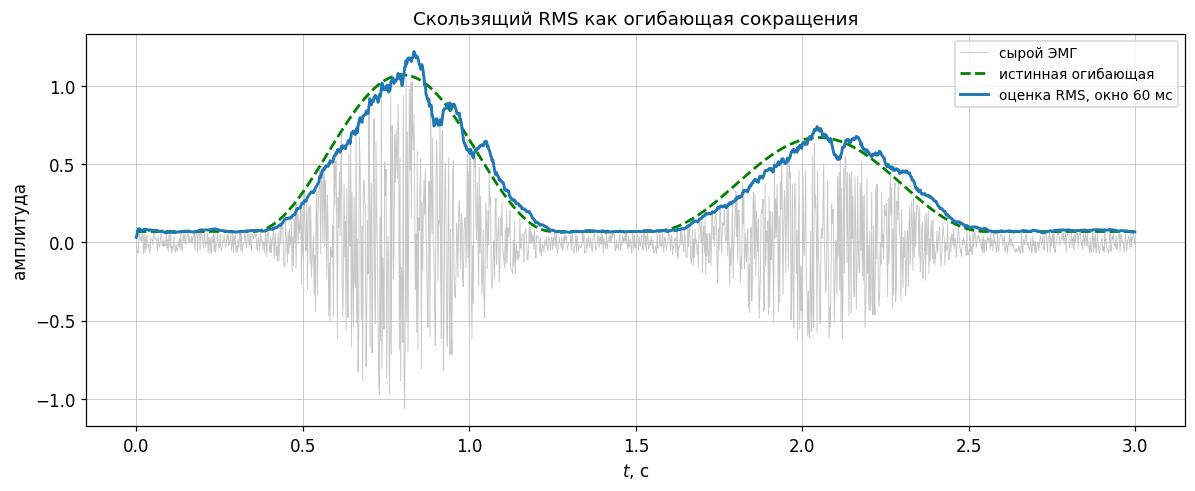

In [4]:
WIN_MS = 60.0    # длина окна, мс
CAUSAL = True    # True — онлайн (окно смотрит назад), False — офлайн (центрировано)

est, width = estimate_envelope(raw, carrier, FS, WIN_MS, CAUSAL)
lag_ms = (width / 2 / FS * 1000) if CAUSAL else 0.0

print("Окно %g мс = %d отсчётов" % (WIN_MS, width))
print("Режим: %s" % ("каузальный (реальное время)" if CAUSAL else "центрированный (офлайн)"))
print("Ожидаемая задержка: примерно %.0f мс" % lag_ms)
print("Средняя ошибка оценки: %.4f" % np.mean(np.abs(est - true_env)))

plot_envelope(t, raw, true_env, [("оценка RMS, окно %g мс" % WIN_MS, est)])

## Ячейка 5 · Главный компромисс: короткое окно против длинного

Сравним три длины окна на одном и том же сигнале.

 окно, мс  отсчётов задержка, мс       ошибка
       20        10           10       0.0410
       60        30           30       0.0392
      200       100          100       0.1008


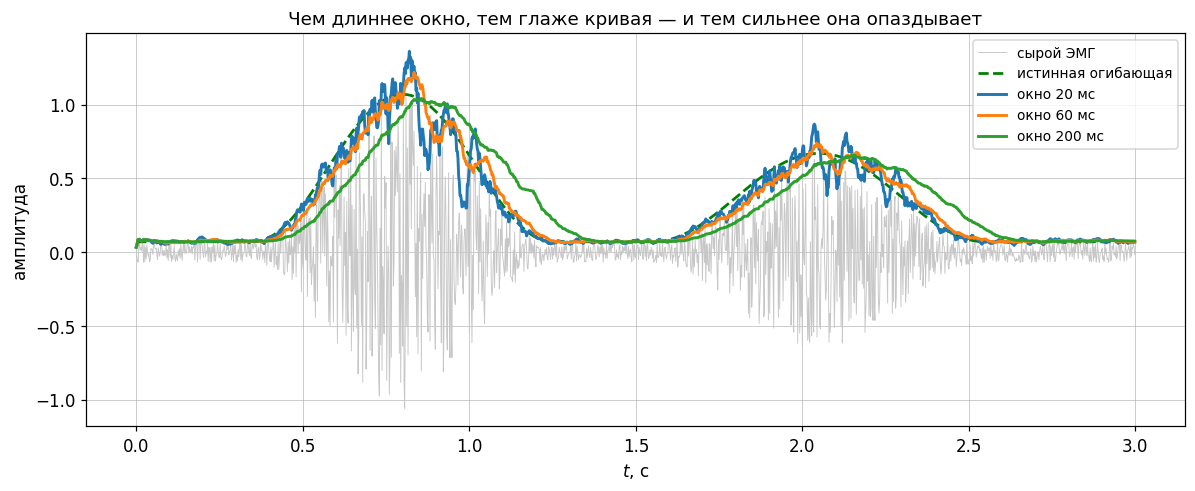

In [5]:
WINDOWS_MS = [20.0, 60.0, 200.0]

estimates = []
print("%9s %9s %12s %12s" % ("окно, мс", "отсчётов", "задержка, мс", "ошибка"))
for win_ms in WINDOWS_MS:
    values, width = estimate_envelope(raw, carrier, FS, win_ms, causal=True)
    estimates.append(("окно %g мс" % win_ms, values))
    print("%9g %9d %12.0f %12.4f"
          % (win_ms, width, width / 2 / FS * 1000, np.mean(np.abs(values - true_env))))

plot_envelope(t, raw, true_env, estimates,
              "Чем длиннее окно, тем глаже кривая — и тем сильнее она опаздывает")

Короткое окно (20 мс) заметно дрожит: клешня от такого сигнала будет
дёргаться. Длинное (200 мс) гладкое, но пик сдвинут вправо — устройство
отреагирует с ощутимым опозданием.

## Ячейка 6 · Каузально против центрированного

То же окно, но в двух режимах. Разница — ровно та задержка, которой в
реальном времени избежать нельзя.

Пик истинной огибающей : 0.800 с
Пик каузальной оценки  : 0.846 с  (опоздание +46 мс)
Пик центрированной     : 0.772 с  (опоздание -28 мс)

Теоретическая задержка каузального окна = W/2 = 75 мс


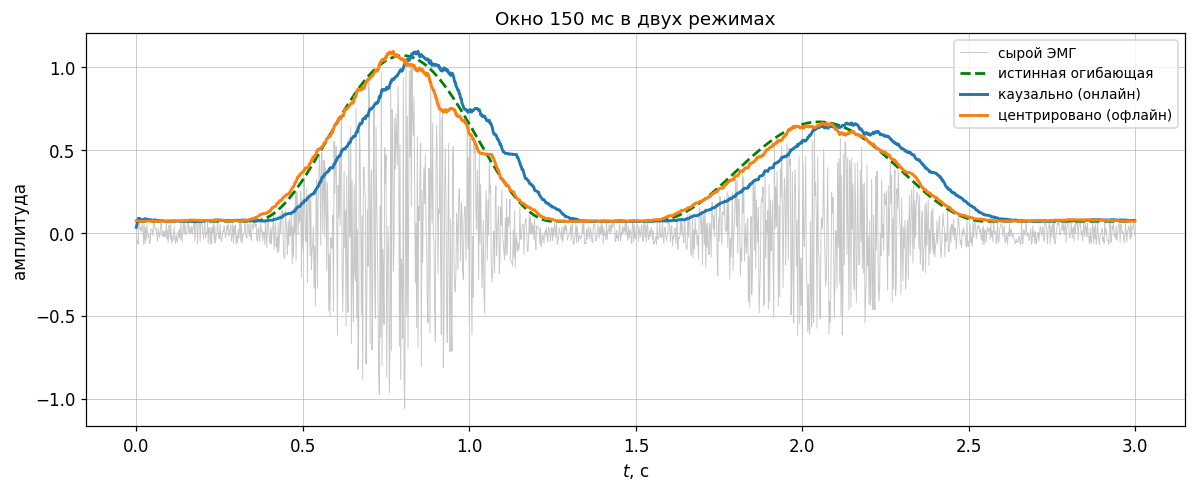

In [6]:
WIN_COMPARE_MS = 150.0

causal_est, width = estimate_envelope(raw, carrier, FS, WIN_COMPARE_MS, causal=True)
centered_est, _ = estimate_envelope(raw, carrier, FS, WIN_COMPARE_MS, causal=False)

peak_true = t[np.argmax(true_env)]
peak_causal = t[np.argmax(causal_est)]
peak_centered = t[np.argmax(centered_est)]
print("Пик истинной огибающей : %.3f с" % peak_true)
print("Пик каузальной оценки  : %.3f с  (опоздание %+.0f мс)"
      % (peak_causal, 1000 * (peak_causal - peak_true)))
print("Пик центрированной     : %.3f с  (опоздание %+.0f мс)"
      % (peak_centered, 1000 * (peak_centered - peak_true)))
print("\nТеоретическая задержка каузального окна = W/2 = %.0f мс"
      % (width / 2 / FS * 1000))

plot_envelope(t, raw, true_env,
              [("каузально (онлайн)", causal_est),
               ("центрировано (офлайн)", centered_est)],
              "Окно %g мс в двух режимах" % WIN_COMPARE_MS)

## Ячейка 7 · Из огибающей — в команду управления

Последний шаг: перевести амплитуду в проценты сжатия. Нужны два уровня —
покой (0%) и максимальное произвольное сокращение (100%). Всё между ними
линейно растягивается, всё за пределами обрезается.

Команда меняется от 0% до 100%
Доля времени с командой больше 50%: 25%


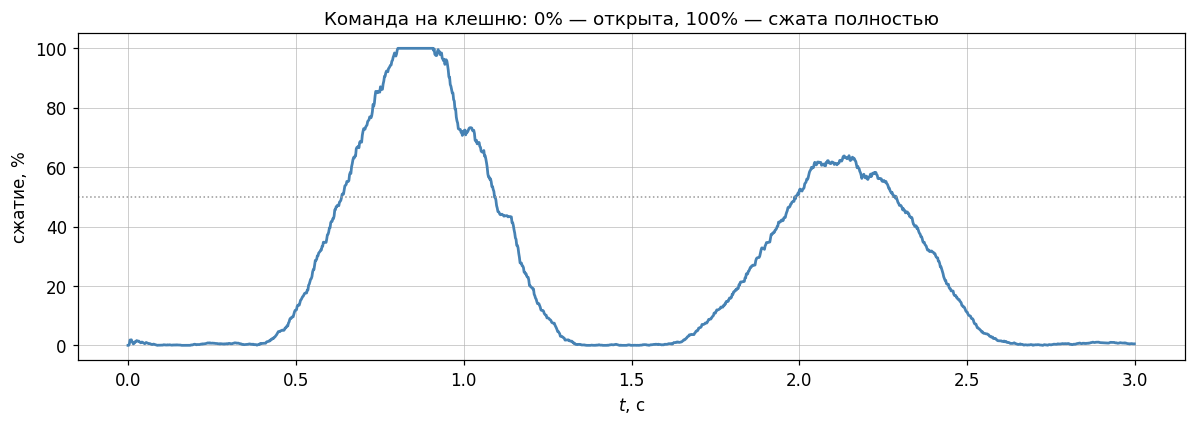

In [7]:
REST_LEVEL = 0.07    # уровень покоя
MVC_LEVEL = 1.0      # максимальное сокращение

command = np.clip((causal_est - REST_LEVEL) / (MVC_LEVEL - REST_LEVEL), 0.0, 1.0) * 100

print("Команда меняется от %.0f%% до %.0f%%" % (command.min(), command.max()))
print("Доля времени с командой больше 50%%: %.0f%%" % (100 * np.mean(command > 50)))

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.plot(t, command, color="steelblue", lw=1.8)
ax.axhline(50, color="0.6", ls=":", lw=1)
ax.set(xlabel="$t$, с", ylabel="сжатие, %", ylim=(-5, 105),
       title="Команда на клешню: 0% — открыта, 100% — сжата полностью")
fig.tight_layout()
plt.show()

## Задания

1. Для своей длины окна из таблицы вариантов запиши число отсчётов $W$,
   расчётную задержку $W/2$ и среднюю ошибку оценки.
2. Найди длину окна, при которой ошибка минимальна. Объясни, почему слишком
   короткое и слишком длинное окно оба дают ошибку больше.
3. Переключи режим на центрированный при том же окне и запиши, как изменилось
   положение пика. Объясни, почему в реальном протезе так сделать нельзя.